# Notebook 5: Euler Sampling with SMC-Ctrl

This notebook uses Euler sampling combined with SMC-Ctrl in denoiser space. At each Euler step, the conditional guidance error is corrected with a sliding-mode control term governed by $k$ and $\lambda$ , and the corrected guidance is then scaled before the Euler update. In the comparisons below,  $k=0$ correspond to standard guided Euler sampling with no SMC control.


### Conclusions

- Gnereation works with SMC-Ctrl.


-  Results varying hyperparameters $k$ and $\lambda$ values:
    -  Higher k:
        - Mode collapse to same point
        - Less diveristy
        - Out of distribution samples

    - Higher lambda:
        - More diversity of samples/ less cluttered trajectories end points

- **For the values probed, adding SMC-Ctrl does not add any advantegous gain regarding diversity. In addition, at some settings, it even produces out-of-distribution samples**.



In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from acg import get_sigmas_karras, sample_heun, ExactDenoiser, ConditionalExactDenoiser
from acg.datasets import make_half_helix, make_gaussian_mixture

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [3]:
from typing import Any, Callable, List, Optional
def sample_euler_smc(
    denoiser: Callable[..., torch.Tensor],
    latents: torch.Tensor,
    sigmas: torch.Tensor,
    condition: torch.Tensor,
    guidance_scale: float = 1.0,
    smc_lambda: float = 1.0,
    smc_k: float = 0.05,
    return_trajectory: bool = False,
    **kwargs: Any,
) -> torch.Tensor:
    """Euler sampling with SMC-CFG applied in denoiser space.

    Implements:
        e_t = D_cond(x_t, sigma_t) - D_uncond(x_t, sigma_t)
        s_t = (e_t - e_prev) + smc_lambda * e_prev
        delta_e = - smc_k * sign(s_t)
        e_hat = e_t + delta_e
        D_hat = D_uncond + guidance_scale * e_hat

    and then uses the usual EDM Euler update:
        d = (x - D_hat) / sigma
        x <- x + d * (sigma_next - sigma)

    Parameters
    ----------
    denoiser : Callable
        Denoiser function D(x, sigma, ...).
    latents : torch.Tensor
        Initial noise of shape [B, ...].
    sigmas : torch.Tensor
        Noise schedule of shape [n_steps + 1], ending with 0.
    condition : torch.Tensor
        Condition tensor for conditional generation.
    guidance_scale : float, optional
        Guidance weight w.
    smc_lambda : float, optional
        Lambda parameter in the sliding surface.
    smc_k : float, optional
        Switching-control strength.
    return_trajectory : bool, optional
        If True, returns all intermediate states.
    **kwargs
        Additional arguments passed to denoiser.

    Returns
    -------
    torch.Tensor
        Generated samples of shape [B, ...].
        If return_trajectory=True, returns [B, n_steps+1, ...].
    """
    if condition is None:
        raise ValueError("sample_euler_smc requires a non-None condition.")

    x = latents
    trajectory: List[torch.Tensor] = []

    # Memory term: previous guidance error
    e_prev = None

    if return_trajectory:
        trajectory.append(x.clone())

    for i in range(len(sigmas) - 1):
        sigma = sigmas[i]
        sigma_next = sigmas[i + 1]

        # Conditional and unconditional denoised predictions
        d_cond = denoiser(x, sigma, condition=condition, **kwargs)
        d_uncond = denoiser(x, sigma, condition=None, **kwargs)

        # Raw guidance error in denoiser space
        e_t = d_cond - d_uncond

        # First step: initialize previous error with current error
        if e_prev is None:
            e_prev = e_t

        # Sliding surface
        s_t = (e_t - e_prev) + smc_lambda * e_prev

        # Switching control
        delta_e = -smc_k * torch.sign(s_t)

        # Updated guidance error
        e_hat = e_t + delta_e

        # Guided denoiser
        denoised = d_uncond + guidance_scale * e_hat

        # Euler step
        d = (x - denoised) / sigma
        dt = sigma_next - sigma
        x = x + d * dt

        # Update memory
        e_prev = e_hat

        if return_trajectory:
            trajectory.append(x.clone())

    if return_trajectory:
        return torch.stack(trajectory, dim=1)

    return x

## 1. Create target distribution

In [4]:

# --------------------------
# 1) Generate dataset
# --------------------------

N = 20000 
x, y, c = make_half_helix(n_samples=N)

print("Shapes:", x.shape, y.shape, c.shape)

Shapes: torch.Size([20000]) torch.Size([20000]) torch.Size([20000])


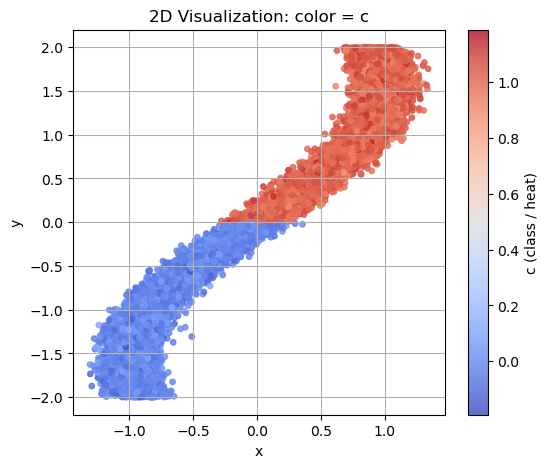

In [5]:

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x, y,
    c=c,
    cmap="coolwarm",   # nice for binary-like values
    s=15,
    alpha=0.8
)

plt.colorbar(sc, label="c (class / heat)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Visualization: color = c")
plt.grid(True)

plt.show()

In [6]:
# Append color and coords
data = torch.stack([x, y, c], dim=1)

# shape: (N, 3) → (x, y, c)

## 2. Conditional generation (without graph decomposition) + SMC-CFG

### 2.1 Initial data

### 2.2  Denoiser

In [7]:
# Create Conditional Exact Denoiser
# Append color and coords
data_xy = torch.stack([x, y], dim=1)
labels_c = labels_c = (c > 0.5).long()

denoiser = ConditionalExactDenoiser(data_xy,labels_c)

print(f"Conditional denoiser created")
print(f"  - Number of classes: {denoiser.n_classes}")
print(f"  - Data points: {denoiser.n_points}")

Conditional denoiser created
  - Number of classes: 2
  - Data points: 20000


In [8]:
# Karras noise schedule
n_steps = 100
sigma_min = 0.01
sigma_max = 2.0

sigmas = get_sigmas_karras(
    n_steps=n_steps,
    sigma_min=sigma_min,
    sigma_max=sigma_max,
    device=device
)

# Scale initial samples
n_samples = 20
latents_2d = torch.randn(n_samples, 2, device=device) * sigmas[0]

print(f"Noise schedule: {n_steps} steps, sigma=[{sigma_min}, {sigma_max}]")

Noise schedule: 100 steps, sigma=[0.01, 2.0]


In [9]:


# Generate Class 0 (blues)
condition_0 = torch.zeros(latents_2d.shape[0], dtype=torch.long, device=device)
traj_class0 = sample_euler_smc(
    denoiser=denoiser,
    latents=latents_2d.clone(),
    sigmas=sigmas,
    condition=condition_0,
    guidance_scale=1.0,  # Pure conditional (no CFG boost)
    return_trajectory=True
)

# Generate Class 1 (reds)
condition_1 = torch.ones(latents_2d.shape[0], dtype=torch.long, device=device)
traj_class1 = sample_euler_smc(
    denoiser=denoiser,
    latents=latents_2d.clone(),
    sigmas=sigmas,
    condition=condition_1,
    guidance_scale=1.0,
    return_trajectory=True
)

print(f"Generated trajectories: {traj_class0.shape}")

Generated trajectories: torch.Size([20, 101, 2])


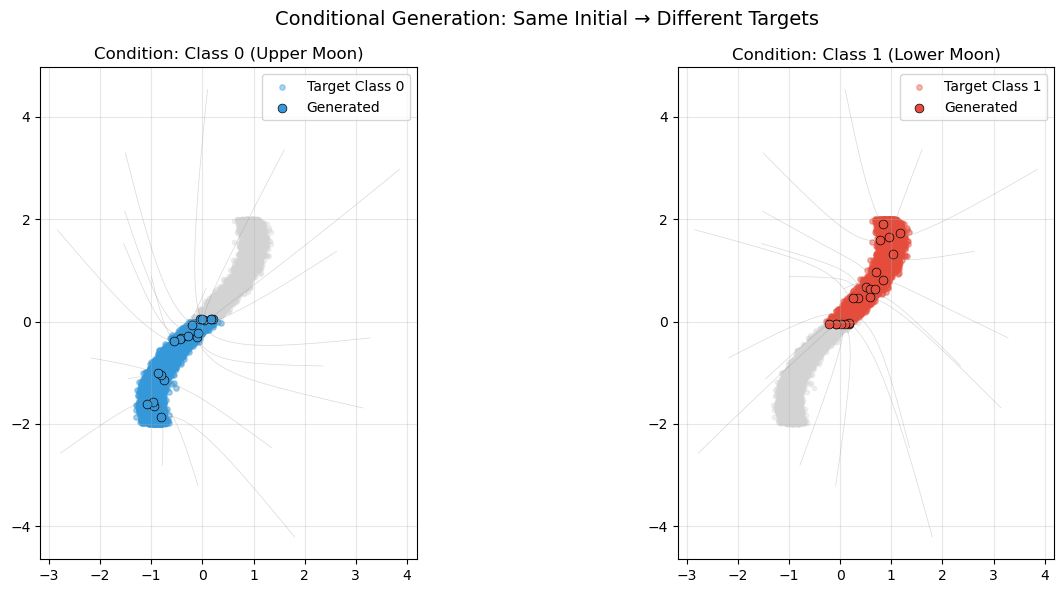

In [10]:
# Visualize: Class 0 vs Class 1 generation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = [ '#3498DB', '#E74C3C']  # Red for class 0, Blue for class 1

target_np = data_xy.cpu().numpy()
labels_np = labels_c.cpu().numpy()

for idx, (traj, target_class, title) in enumerate([
    (traj_class0, 0, 'Condition: Class 0 (Upper Moon)'),
    (traj_class1, 1, 'Condition: Class 1 (Lower Moon)')
]):
    ax = axes[idx]
    traj_np = traj.cpu().numpy()
    
    # Plot target data (both classes in gray)
    ax.scatter(target_np[:, 0], target_np[:, 1], c='lightgray', alpha=0.3, s=10)
    
    # Highlight target class
    mask = labels_np == target_class
    ax.scatter(
        target_np[mask, 0], target_np[mask, 1],
        c=colors[target_class], alpha=0.4, s=15, label=f'Target Class {target_class}'
    )
    
    # Plot trajectories
    for i in range(traj_np.shape[0]):
        ax.plot(traj_np[i, :, 0], traj_np[i, :, 1], '-', color='gray', alpha=0.3, linewidth=0.5)
    
    # Plot final samples
    ax.scatter(
        traj_np[:, -1, 0], traj_np[:, -1, 1],
        c=colors[target_class], s=40, edgecolors='black', linewidth=0.5,
        label='Generated'
    )
    
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Conditional Generation: Same Initial → Different Targets', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Generate with different CFG scales for Class 0
cfg_scales = [1.0, 3.0, 5.0, 7.0, 20.0, 50.0]
target_class = 1  # Focus on class 1

condition = torch.full((latents_2d.shape[0],), target_class, dtype=torch.long, device=device)

trajectories_cfg = {}
for cfg_scale in cfg_scales:
    traj = sample_euler_smc(
        denoiser=denoiser,
        latents=latents_2d.clone(),
        sigmas=sigmas,
        condition=condition,
        guidance_scale=cfg_scale,
        return_trajectory=True
    )
    trajectories_cfg[cfg_scale] = traj
    print(f"CFG scale {cfg_scale}: done")


CFG scale 1.0: done
CFG scale 3.0: done
CFG scale 5.0: done
CFG scale 7.0: done
CFG scale 20.0: done
CFG scale 50.0: done


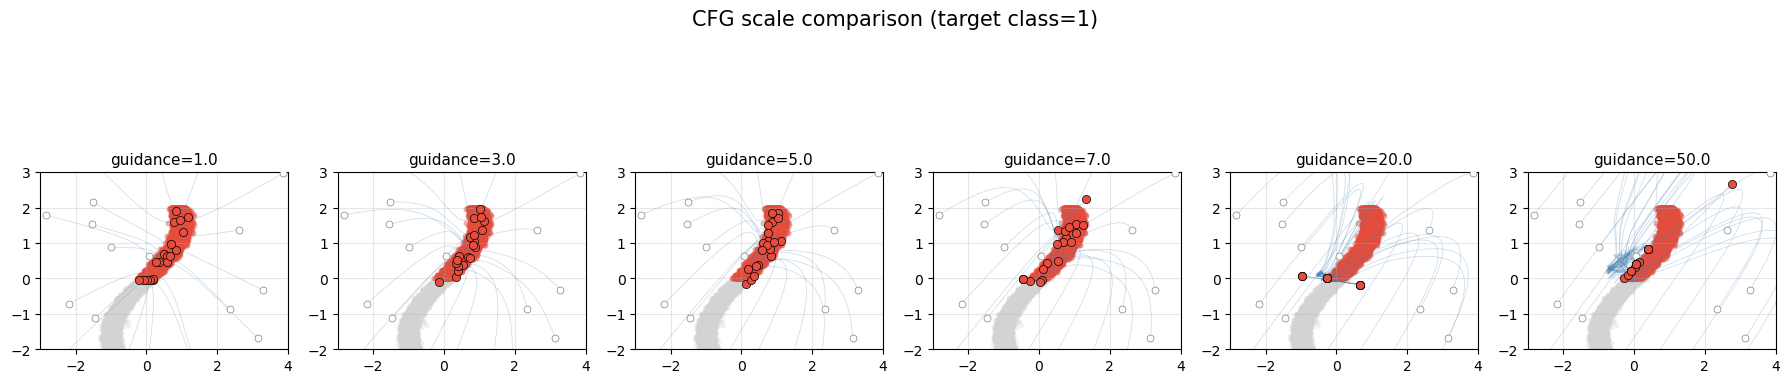

In [12]:
# Visualize CFG scale comparison
fig, axes = plt.subplots(1, 6, figsize=(18, 4.5))

target_np = data_xy.cpu().numpy()
labels_np = labels_c.cpu().numpy()
mask = labels_np == target_class

for idx, cfg_scale in enumerate(cfg_scales):
    ax = axes[idx]
    traj_np = trajectories_cfg[cfg_scale].cpu().numpy()

    ax.scatter(target_np[:, 0], target_np[:, 1], c='lightgray', alpha=0.25, s=8)
    ax.scatter(target_np[mask, 0], target_np[mask, 1], c=colors[target_class], alpha=0.3, s=12)

    for b in range(traj_np.shape[0]):
        ax.plot(
            traj_np[b, :, 0], traj_np[b, :, 1],
            '-', color='steelblue', alpha=0.25, linewidth=0.6
        )

    ax.scatter(
        traj_np[:, 0, 0], traj_np[:, 0, 1],
        c='white', s=25, edgecolors='gray', linewidth=0.5, zorder=5
    )
    ax.scatter(
        traj_np[:, -1, 0], traj_np[:, -1, 1],
        c=colors[target_class], s=35, edgecolors='black', linewidth=0.5, zorder=6
    )

    ax.set_title(f'guidance={cfg_scale}', fontsize=11)
    ax.set_xlim(-3, 4)
    ax.set_ylim(-2, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'CFG scale comparison (target class={target_class})',
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()


In [13]:
# Generate with different CFG scales for Class 0
cfg_scales = [8.0, 9.0, 10.0, 12.0, 15.0, 18.0]
target_class = 1  # Focus on class 1

condition = torch.full((latents_2d.shape[0],), target_class, dtype=torch.long, device=device)

trajectories_cfg = {}
for cfg_scale in cfg_scales:
    traj = sample_euler_smc(
        denoiser=denoiser,
        latents=latents_2d.clone(),
        sigmas=sigmas,
        condition=condition,
        guidance_scale=cfg_scale,
        return_trajectory=True
    )
    trajectories_cfg[cfg_scale] = traj
    print(f"CFG scale {cfg_scale}: done")


CFG scale 8.0: done
CFG scale 9.0: done
CFG scale 10.0: done
CFG scale 12.0: done
CFG scale 15.0: done
CFG scale 18.0: done


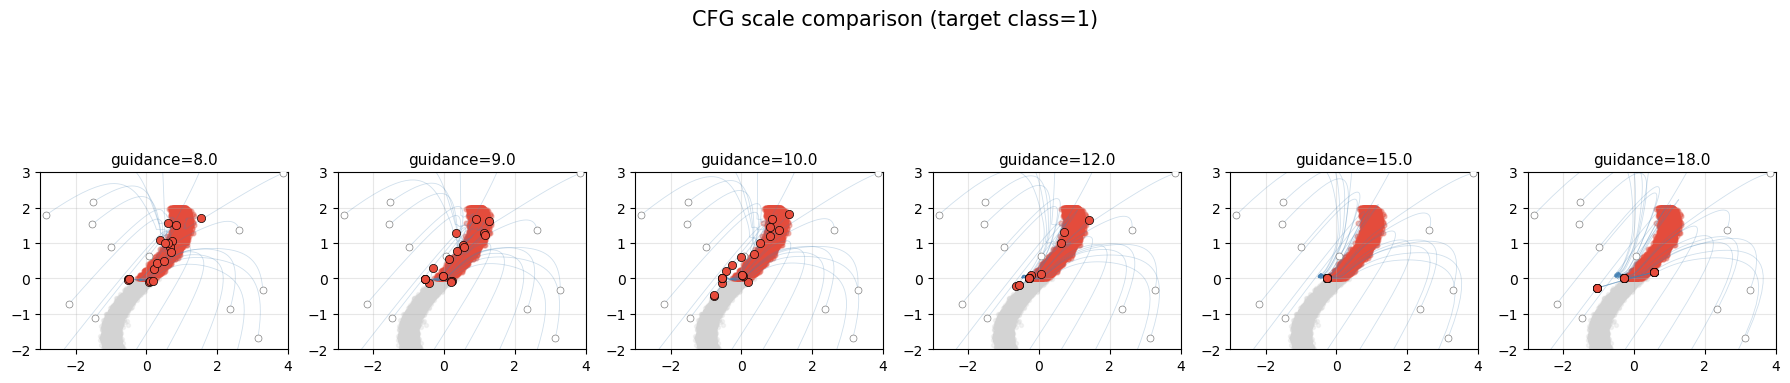

In [14]:
# Visualize CFG scale comparison
fig, axes = plt.subplots(1, 6, figsize=(18, 4.5))

target_np = data_xy.cpu().numpy()
labels_np = labels_c.cpu().numpy()
mask = labels_np == target_class

for idx, cfg_scale in enumerate(cfg_scales):
    ax = axes[idx]
    traj_np = trajectories_cfg[cfg_scale].cpu().numpy()

    ax.scatter(target_np[:, 0], target_np[:, 1], c='lightgray', alpha=0.25, s=8)
    ax.scatter(target_np[mask, 0], target_np[mask, 1], c=colors[target_class], alpha=0.3, s=12)

    for b in range(traj_np.shape[0]):
        ax.plot(
            traj_np[b, :, 0], traj_np[b, :, 1],
            '-', color='steelblue', alpha=0.25, linewidth=0.6
        )

    ax.scatter(
        traj_np[:, 0, 0], traj_np[:, 0, 1],
        c='white', s=25, edgecolors='gray', linewidth=0.5, zorder=5
    )
    ax.scatter(
        traj_np[:, -1, 0], traj_np[:, -1, 1],
        c=colors[target_class], s=35, edgecolors='black', linewidth=0.5, zorder=6
    )

    ax.set_title(f'guidance={cfg_scale}', fontsize=11)
    ax.set_xlim(-3, 4)
    ax.set_ylim(-2, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f'CFG scale comparison (target class={target_class})',
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()


In [15]:
# --------------------------
# Fixed setup
# --------------------------
guidance_scale = 10.0
target_class = 1

condition = torch.full(
    (latents_2d.shape[0],),
    target_class,
    dtype=torch.long,
    device=device
)

# Parameter grid
lambda_values = [0.0, 0.25, 0.5, 1.0, 2.0]
k_values = [0.001, 0.005, 0.01, 0.02, 0.05]

# Store trajectories
trajectories_smc = {}

for smc_lambda in lambda_values:
    for smc_k in k_values:
        traj = sample_euler_smc(
            denoiser=denoiser,
            latents=latents_2d.clone(),
            sigmas=sigmas,
            condition=condition,
            guidance_scale=guidance_scale,
            smc_lambda=smc_lambda,
            smc_k=smc_k,
            return_trajectory=True
        )
        trajectories_smc[(smc_lambda, smc_k)] = traj
        print(f"Done: lambda={smc_lambda}, k={smc_k}, traj shape={traj.shape}")


Done: lambda=0.0, k=0.001, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.0, k=0.005, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.0, k=0.01, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.0, k=0.02, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.0, k=0.05, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.25, k=0.001, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.25, k=0.005, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.25, k=0.01, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.25, k=0.02, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.25, k=0.05, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.5, k=0.001, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.5, k=0.005, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.5, k=0.01, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.5, k=0.02, traj shape=torch.Size([20, 101, 2])
Done: lambda=0.5, k=0.05, traj shape=torch.Size([20, 101, 2])
Done: lambda=1.0, k=0.001, traj shape=torch.Size([20, 101, 

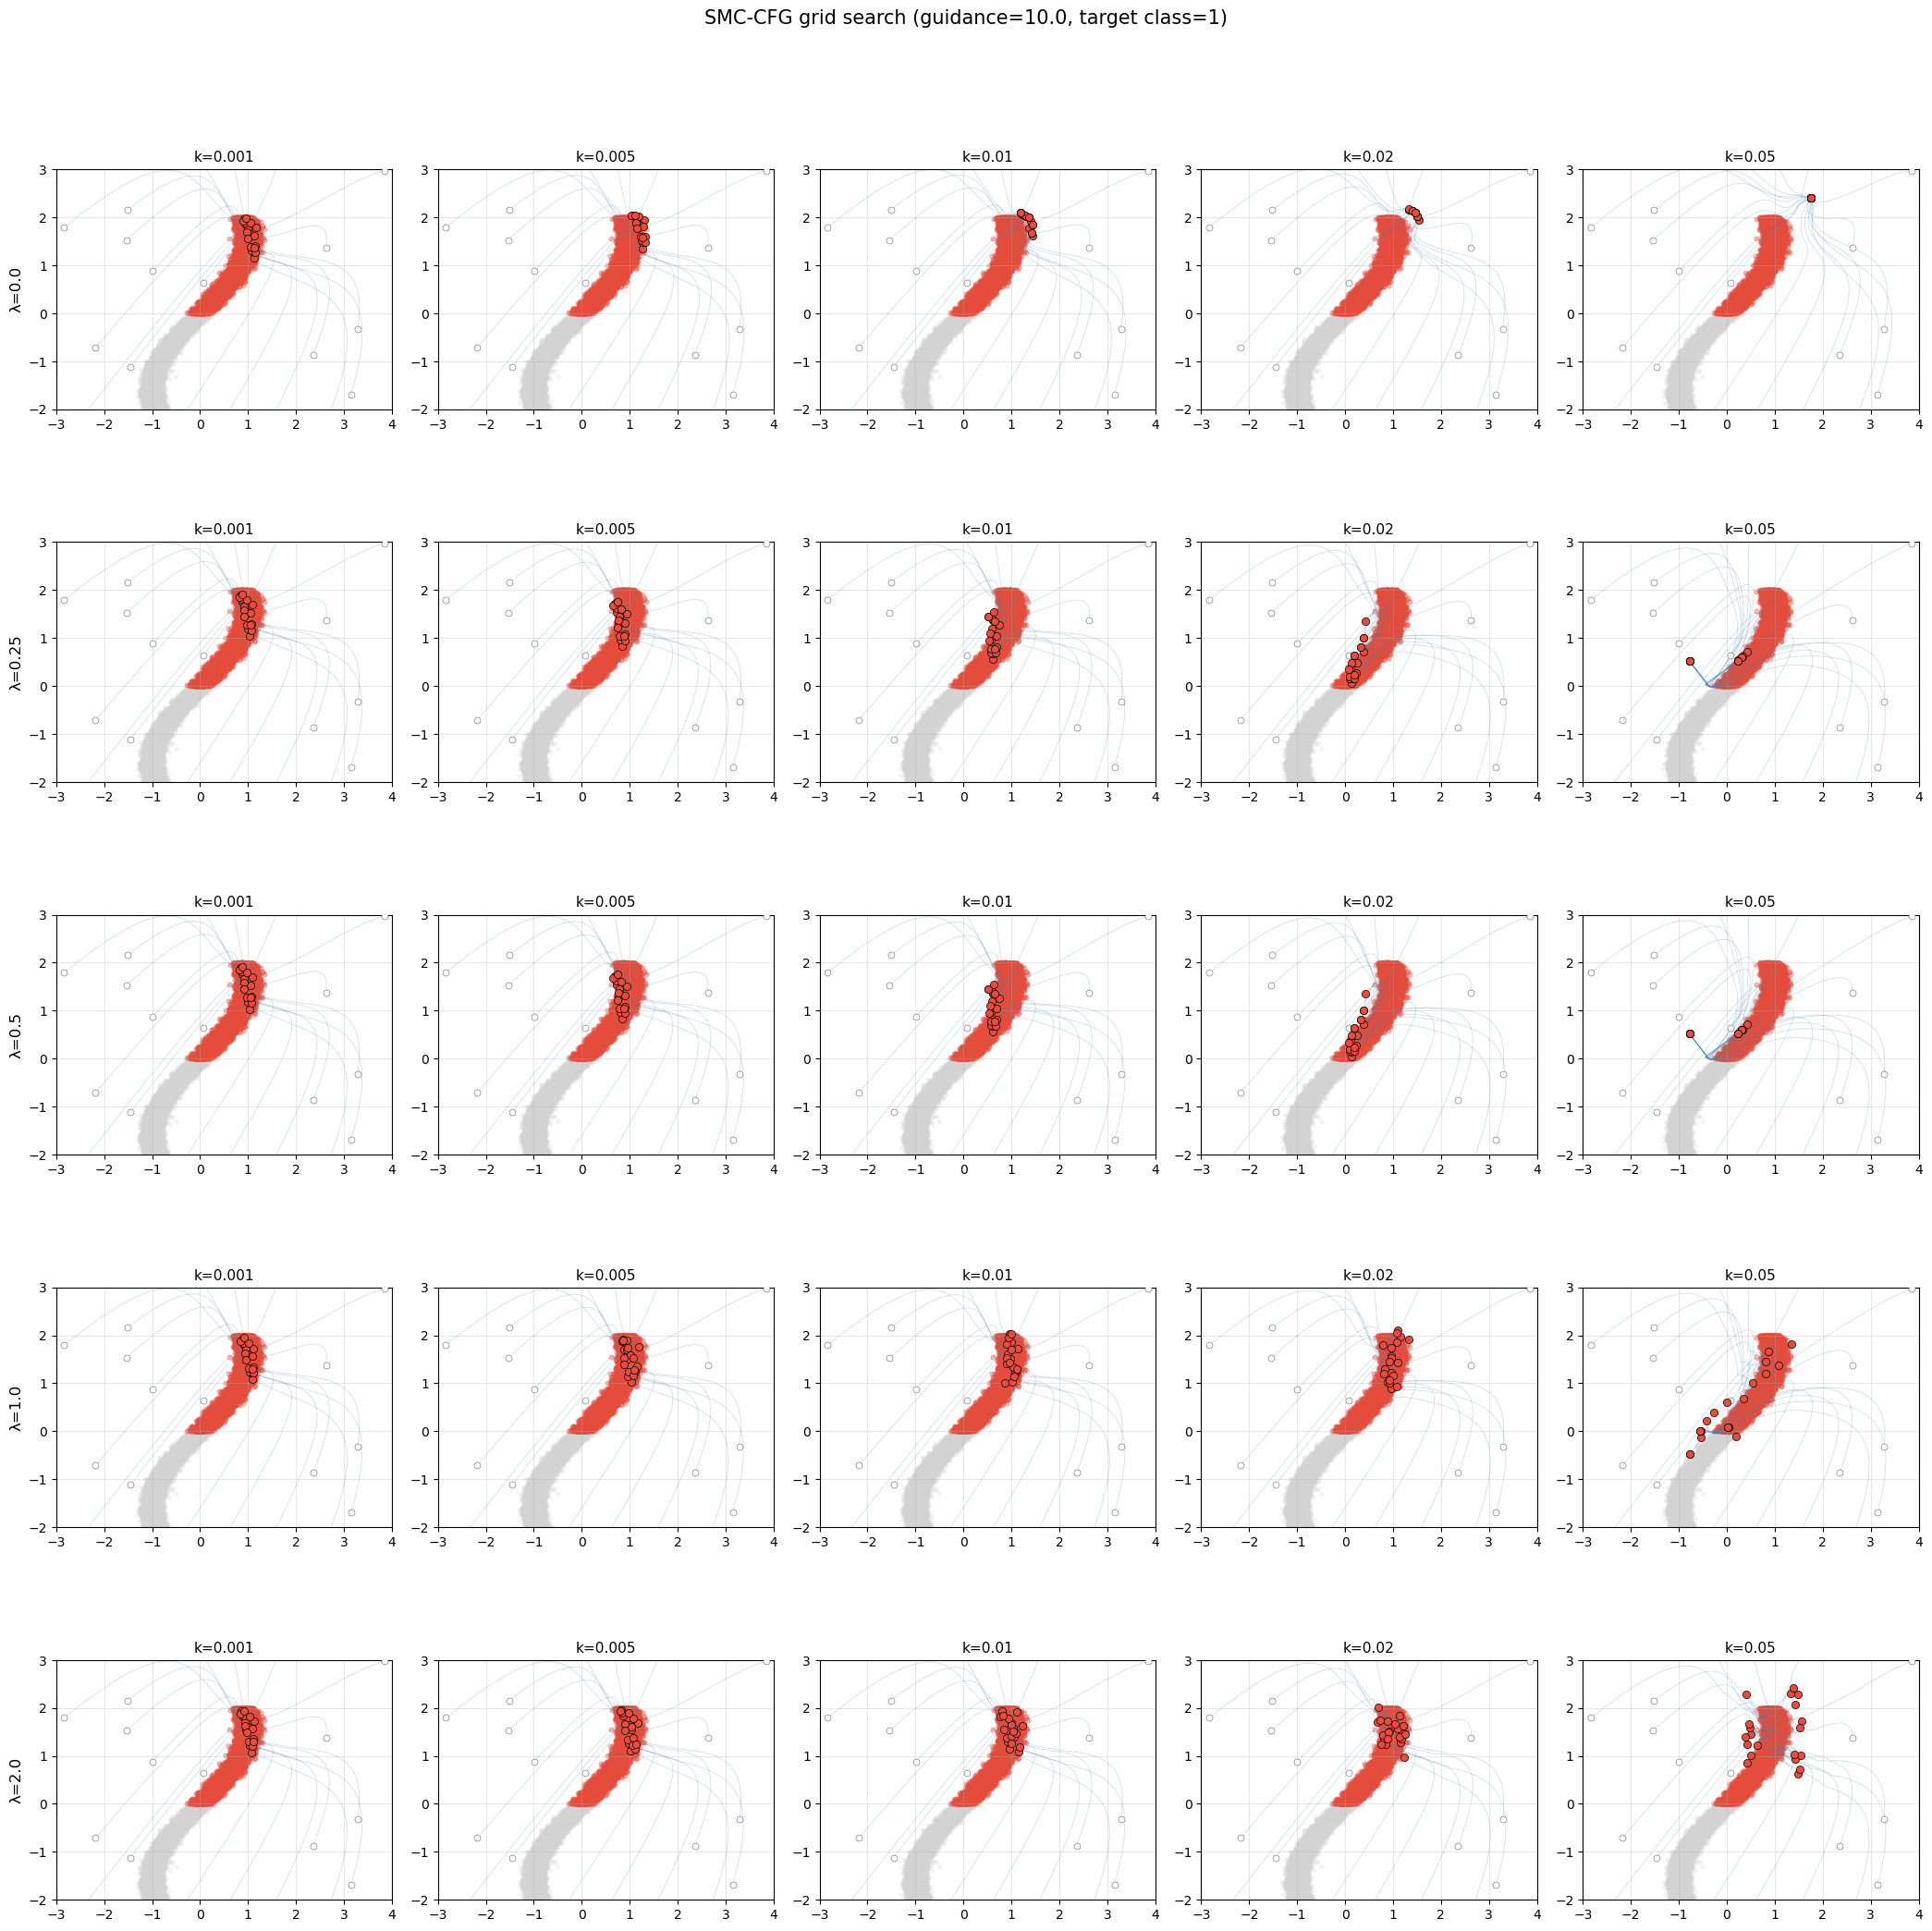

In [16]:
fig, axes = plt.subplots(
    len(lambda_values), len(k_values),
    figsize=(4.2 * len(k_values), 4.2 * len(lambda_values)),
    squeeze=False
)

target_np = data_xy.cpu().numpy()
labels_np = labels_c.cpu().numpy()
mask = labels_np == target_class

for i, smc_lambda in enumerate(lambda_values):
    for j, smc_k in enumerate(k_values):
        ax = axes[i, j]
        traj_np = trajectories_smc[(smc_lambda, smc_k)].cpu().numpy()

        # Background data
        ax.scatter(
            target_np[:, 0], target_np[:, 1],
            c='lightgray', alpha=0.2, s=8
        )

        # Target class
        ax.scatter(
            target_np[mask, 0], target_np[mask, 1],
            c=colors[target_class], alpha=0.3, s=12
        )

        # Trajectories
        for b in range(traj_np.shape[0]):
            ax.plot(
                traj_np[b, :, 0], traj_np[b, :, 1],
                '-', color='steelblue', alpha=0.25, linewidth=0.6
            )

        # Start points
        ax.scatter(
            traj_np[:, 0, 0], traj_np[:, 0, 1],
            c='white', s=25, edgecolors='gray', linewidth=0.5, zorder=5
        )

        # Final points
        ax.scatter(
            traj_np[:, -1, 0], traj_np[:, -1, 1],
            c=colors[target_class], s=35, edgecolors='black', linewidth=0.5, zorder=6
        )

        ax.set_title(f'k={smc_k}', fontsize=11)
        ax.set_xlim(-3, 4)
        ax.set_ylim(-2, 3)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

        if j == 0:
            ax.set_ylabel(f'λ={smc_lambda}', fontsize=12)

fig.suptitle(
    f'SMC-CFG grid search (guidance={guidance_scale}, target class={target_class})',
    fontsize=15,
    y=1.02
)
plt.tight_layout()
plt.show()


### Interpretation

-  Higher k:
    - Mode collapse to same point
    - Less diveristy
    - Out of distribution samples

- Higher lambda:
    - More diversity of samples/ less cluttered trajectories end points


### 2.4 Guidance-scale comparison with and without SMC-CTRL



In [19]:
guidance_scales = [1.0, 10.0, 20.0, 40.0]
target_class = 1

condition = torch.full(
    (latents_2d.shape[0],),
    target_class,
    dtype=torch.long,
    device=device
)

smc_configs = [(0.0, 0.0)] + [
    (smc_lambda, smc_k)
    for smc_lambda in [0.5, 2.0, 5.0]
    for smc_k in [0.001, 0.005, 0.01]
]

trajectories_comparison = {}
for smc_lambda, smc_k in smc_configs:
    for guidance_scale in guidance_scales:
        traj = sample_euler_smc(
            denoiser=denoiser,
            latents=latents_2d.clone(),
            sigmas=sigmas,
            condition=condition,
            guidance_scale=guidance_scale,
            smc_lambda=smc_lambda,
            smc_k=smc_k,
            return_trajectory=True
        )
        trajectories_comparison[(smc_lambda, smc_k, guidance_scale)] = traj
        print(
            f'guidance={guidance_scale:>4}, lambda={smc_lambda:>3}, k={smc_k:>5}: done'
        )


guidance= 1.0, lambda=0.0, k=  0.0: done
guidance=10.0, lambda=0.0, k=  0.0: done
guidance=20.0, lambda=0.0, k=  0.0: done
guidance=40.0, lambda=0.0, k=  0.0: done
guidance= 1.0, lambda=0.5, k=0.001: done
guidance=10.0, lambda=0.5, k=0.001: done
guidance=20.0, lambda=0.5, k=0.001: done
guidance=40.0, lambda=0.5, k=0.001: done
guidance= 1.0, lambda=0.5, k=0.005: done
guidance=10.0, lambda=0.5, k=0.005: done
guidance=20.0, lambda=0.5, k=0.005: done
guidance=40.0, lambda=0.5, k=0.005: done
guidance= 1.0, lambda=0.5, k= 0.01: done
guidance=10.0, lambda=0.5, k= 0.01: done
guidance=20.0, lambda=0.5, k= 0.01: done
guidance=40.0, lambda=0.5, k= 0.01: done
guidance= 1.0, lambda=2.0, k=0.001: done
guidance=10.0, lambda=2.0, k=0.001: done
guidance=20.0, lambda=2.0, k=0.001: done
guidance=40.0, lambda=2.0, k=0.001: done
guidance= 1.0, lambda=2.0, k=0.005: done
guidance=10.0, lambda=2.0, k=0.005: done
guidance=20.0, lambda=2.0, k=0.005: done
guidance=40.0, lambda=2.0, k=0.005: done
guidance= 1.0, l

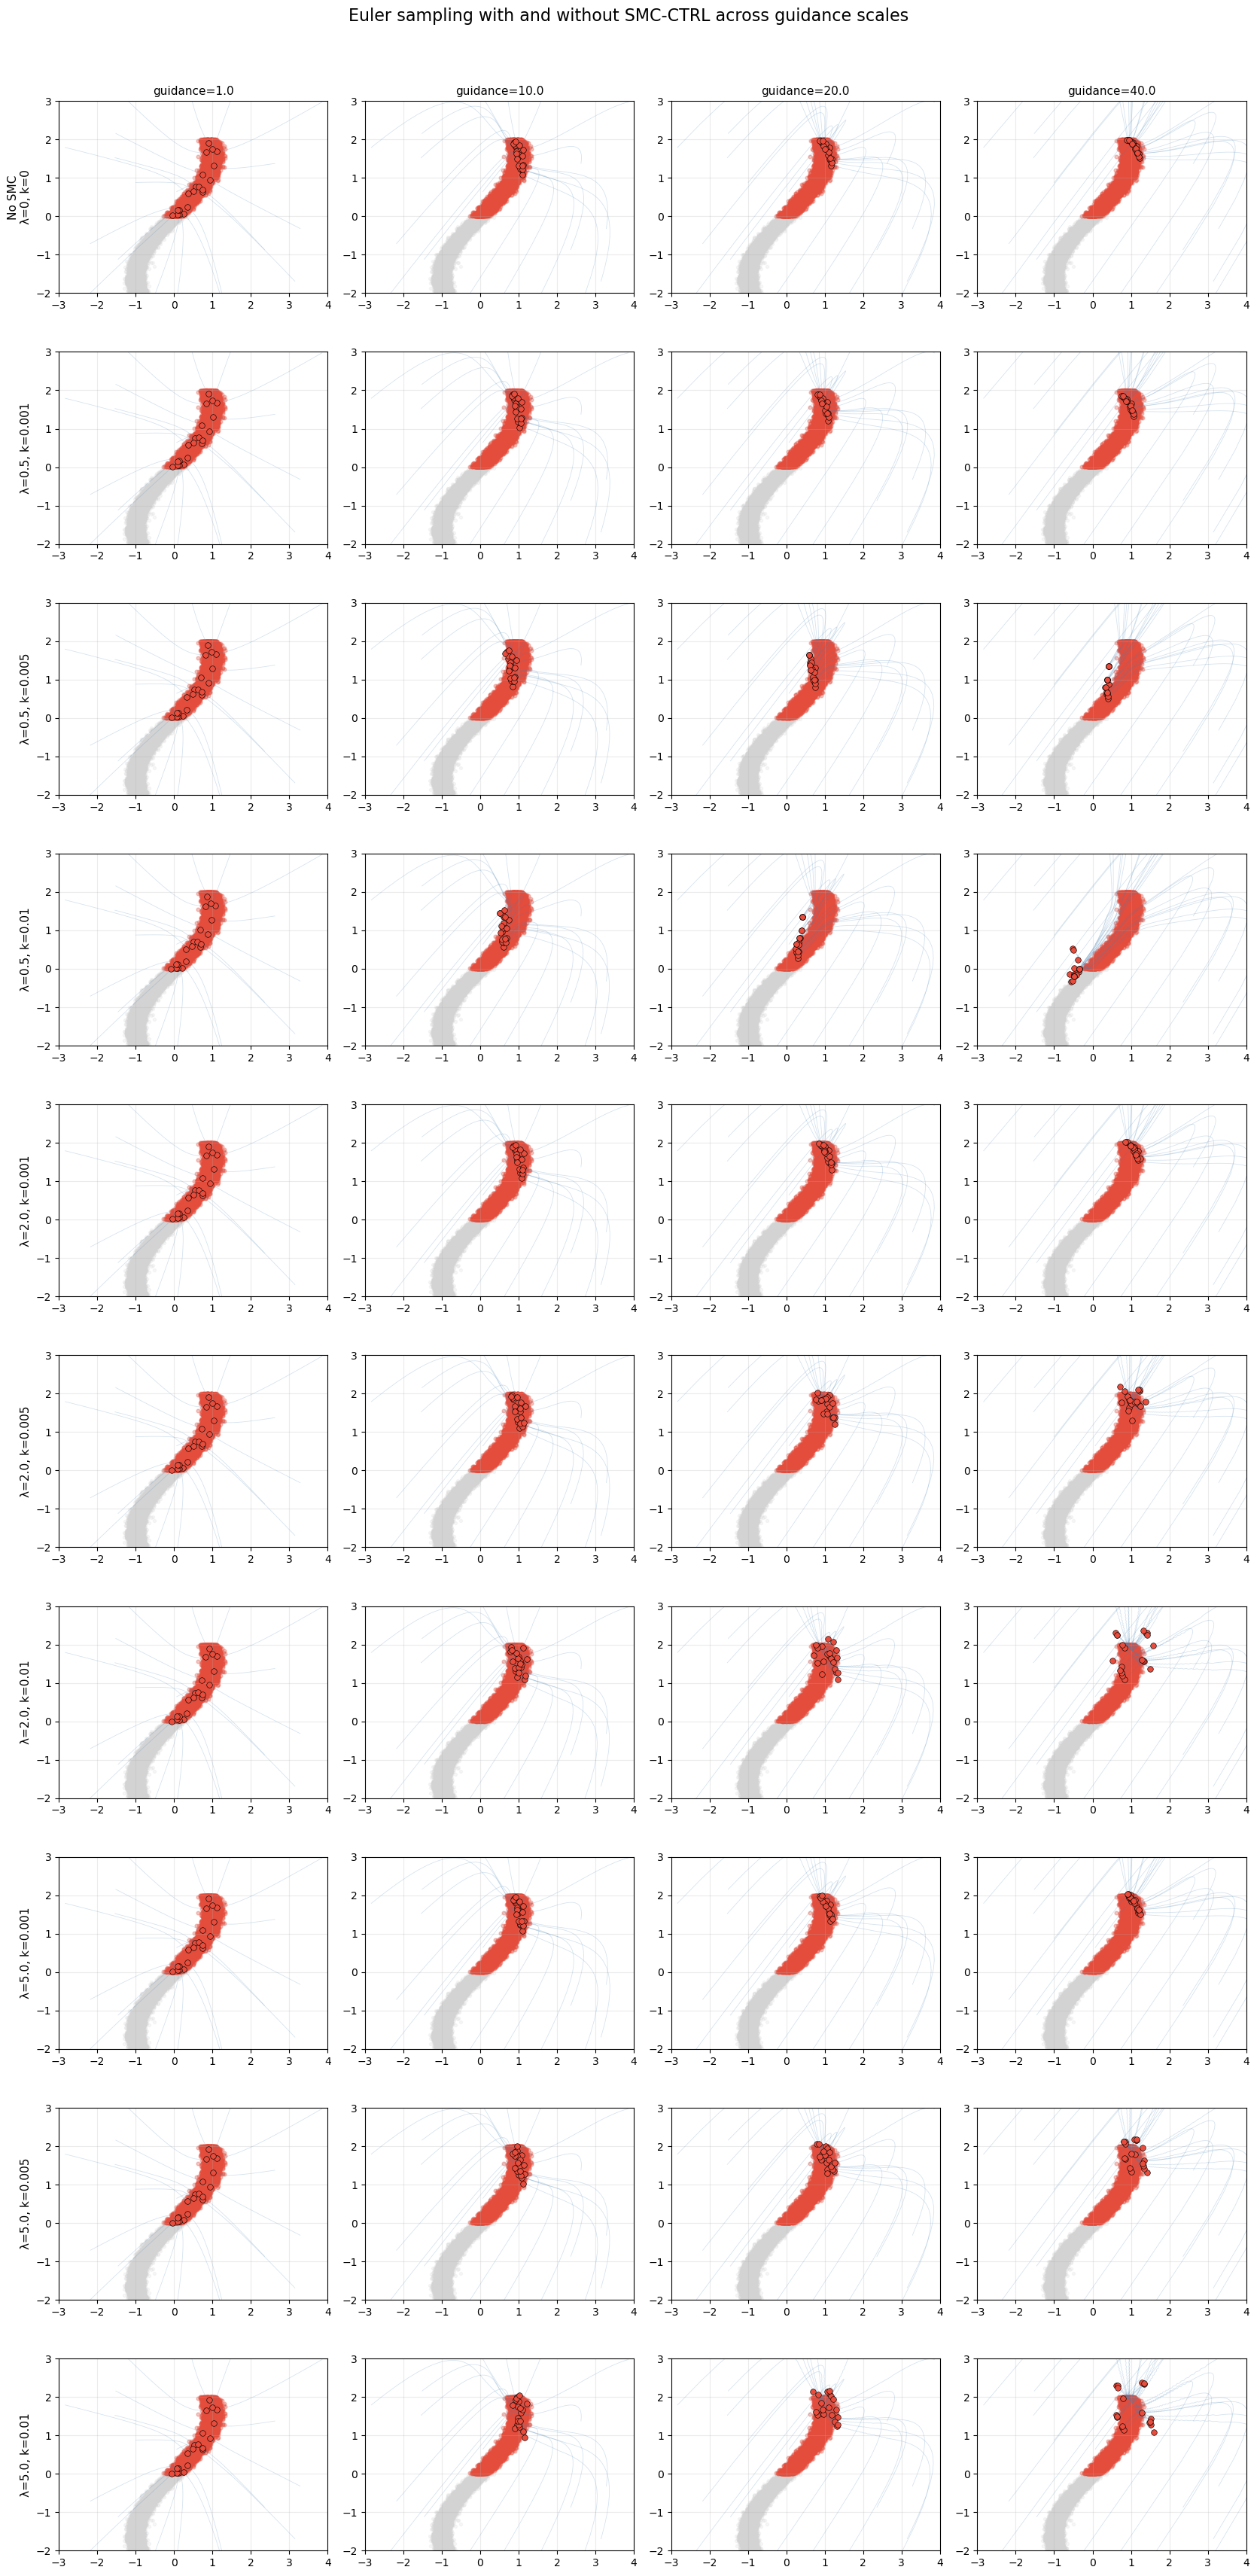

In [20]:
fig, axes = plt.subplots(
    len(smc_configs), len(guidance_scales),
    figsize=(4.2 * len(guidance_scales), 3.4 * len(smc_configs)),
    squeeze=False
)

target_np = data_xy.cpu().numpy()
labels_np = labels_c.cpu().numpy()
mask = labels_np == target_class

for i, (smc_lambda, smc_k) in enumerate(smc_configs):
    for j, guidance_scale in enumerate(guidance_scales):
        ax = axes[i, j]
        traj_np = trajectories_comparison[(smc_lambda, smc_k, guidance_scale)].cpu().numpy()

        ax.scatter(
            target_np[:, 0], target_np[:, 1],
            c='lightgray', alpha=0.18, s=8
        )
        ax.scatter(
            target_np[mask, 0], target_np[mask, 1],
            c=colors[target_class], alpha=0.28, s=12
        )

        for b in range(traj_np.shape[0]):
            ax.plot(
                traj_np[b, :, 0], traj_np[b, :, 1],
                '-', color='steelblue', alpha=0.22, linewidth=0.6
            )

        ax.scatter(
            traj_np[:, -1, 0], traj_np[:, -1, 1],
            c=colors[target_class], s=30, edgecolors='black', linewidth=0.45, zorder=5
        )

        if i == 0:
            ax.set_title(f'guidance={guidance_scale}', fontsize=11)

        if j == 0:
            if smc_lambda == 0.0 and smc_k == 0.0:
                row_label = 'No SMC\nλ=0, k=0'
            else:
                row_label = f'λ={smc_lambda}, k={smc_k}'
            ax.set_ylabel(row_label, fontsize=11)

        ax.set_xlim(-3, 4)
        ax.set_ylim(-2, 3)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.25)

fig.suptitle(
    'Euler sampling with and without SMC-CTRL across guidance scales',
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()
